# Game-Start Free Building Levels

Reads `free_building_levels` weights from `graphs/building_capacity/data/free_building_levels_sheet.csv`, enriches the generated static location parquet with game-start parser data, and computes where free building capacity would be available.


In [12]:
%matplotlib inline

from pathlib import Path
import os

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from prosper_or_perish_constructor.free_building_levels import (
    DEFAULT_DISPLAY_DECIMALS,
    LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
    LOCAL_CONSTRUCTION_SPEED_COLUMN,
    build_location_map_frame,
    compute_free_building_levels,
    compute_local_build_buildings_efficiency,
    compute_local_construction_speed,
    contribution_category_summary,
    contribution_factor_group_summary,
    contribution_value_summary,
    explain_development_components,
    load_free_building_level_weights,
    load_game_start_development_weights,
    load_free_building_level_location_frame,
    local_free_building_levels_sheet_csv_path,
    round_numeric_columns,
    summarize_free_building_levels,
    validate_sheet_values_against_game_sources,
)

pl.Config.set_float_precision(DEFAULT_DISPLAY_DECIMALS)
pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(30)


def find_repo(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "constructor.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find constructor.toml above current working directory")


REPO = find_repo(Path.cwd().resolve())
PROJECT = REPO / "constructor.toml"
print(f"repo={REPO}")
print(f"project={PROJECT}")


def color_limits(values: pl.Series) -> tuple[float, float]:
    vmin = float(values.min())
    vmax = float(values.max())
    if vmin == vmax:
        spread = max(abs(vmin) * 0.05, 0.5)
        vmin -= spread
        vmax += spread
    return vmin, vmax


def plot_location_world_map(
    frame: pl.DataFrame,
    value_column: str,
    *,
    title: str,
    cmap: str = "viridis",
    point_size: float = 3,
) -> None:
    plt.close("all")
    plot_data = frame.select("approx_lon", "approx_lat", value_column).to_dict(as_series=False)
    vmin, vmax = color_limits(frame[value_column])
    fig, ax = plt.subplots(figsize=(16, 8), dpi=140)
    scatter = ax.scatter(
        plot_data["approx_lon"],
        plot_data["approx_lat"],
        c=plot_data[value_column],
        s=point_size,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
        alpha=0.85,
    )
    ax.set_xlim(-180, 180)
    ax.set_ylim(-65, 85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label=value_column)
    ax.grid(alpha=0.15)
    plt.show()


repo=/home/jan/development/ProsperOrPerishConstructor
project=/home/jan/development/ProsperOrPerishConstructor/constructor.toml


## At-a-glance Rank Math

These tables use the same game-start `scores` frame as the detailed sections below. `mean_free_building_levels` is the average free-building-level value for the settlement rank.


In [23]:
RANK_ORDER = ["rural_settlement", "town", "city", "megalopolis"]


def rank_order_expr() -> pl.Expr:
    return (
        pl.when(pl.col("location_rank") == "rural_settlement").then(pl.lit(0))
        .when(pl.col("location_rank") == "town").then(pl.lit(1))
        .when(pl.col("location_rank") == "city").then(pl.lit(2))
        .when(pl.col("location_rank") == "megalopolis").then(pl.lit(3))
        .otherwise(pl.lit(99))
        .alias("rank_order")
    )


def summarize_rank_building_levels(
    frame: pl.DataFrame,
    group_by: list[str] | None = None,
) -> pl.DataFrame:
    group_columns = list(group_by or [])
    return round_numeric_columns(
        frame
        .filter(pl.col("location_rank").is_in(RANK_ORDER))
        .group_by([*group_columns, "location_rank"])
        .agg(
            pl.len().alias("locations"),
            pl.col("free_building_levels").min().alias("min_free_building_levels"),
            pl.col("free_building_levels").mean().alias("mean_free_building_levels"),
            pl.col("free_building_levels").median().alias("median_free_building_levels"),
            pl.col("free_building_levels").max().alias("max_free_building_levels"),
        )
        .with_columns(rank_order_expr())
        .sort([*group_columns, "rank_order"])
        .drop("rank_order")
    )


sheet_csv = local_free_building_levels_sheet_csv_path(REPO)
weights = load_free_building_level_weights(REPO)
locations = load_free_building_level_location_frame(REPO, PROJECT)
result = compute_free_building_levels(locations, weights)
scores = result.frame
efficiency_scores = compute_local_build_buildings_efficiency(locations, weights)
construction_speed_scores = compute_local_construction_speed(locations, weights)
scores = scores.join(
    efficiency_scores.select("location_tag", LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN),
    on="location_tag",
    how="left",
).join(
    construction_speed_scores.select("location_tag", LOCAL_CONSTRUCTION_SPEED_COLUMN),
    on="location_tag",
    how="left",
)

global_rank_summary = summarize_rank_building_levels(scores)
super_region_rank_summary = summarize_rank_building_levels(scores, group_by=["super_region"])

display(Markdown("### Global min / mean / median / max by settlement rank"))
display(global_rank_summary)
display(Markdown("### Super-region min / mean / median / max by settlement rank"))
display(super_region_rank_summary)


### Global min / mean / median / max by settlement rank

location_rank,locations,min_free_building_levels,mean_free_building_levels,median_free_building_levels,max_free_building_levels
str,u32,f64,f64,f64,f64
"""rural_settlement""",19915,-43.00,29.36,30.00,105.65
"""town""",749,-17.60,65.13,64.90,147.35
"""city""",262,17.05,96.98,94.85,179.75
"""megalopolis""",3,138.75,153.18,153.50,167.30


### Super-region min / mean / median / max by settlement rank

super_region,location_rank,locations,min_free_building_levels,mean_free_building_levels,median_free_building_levels,max_free_building_levels
str,str,u32,f64,f64,f64,f64
"""africa""","""rural_settlement""",2363,-31.00,28.38,27.20,105.65
"""africa""","""town""",42,11.10,67.24,63.72,143.65
"""africa""","""city""",27,47.00,90.67,84.78,160.15
"""africa""","""megalopolis""",1,138.75,138.75,138.75,138.75
"""america""","""rural_settlement""",4416,-43.00,26.46,30.00,90.05
"""america""","""town""",16,22.70,64.04,49.50,123.00
"""america""","""city""",9,43.00,70.40,64.80,103.60
"""asia""","""rural_settlement""",7492,-41.80,25.71,25.00,101.20
"""asia""","""town""",331,-17.60,57.04,58.70,112.85


## Source Weights

`graphs/building_capacity/data/free_building_levels_sheet.csv` is the source of truth. It uses one tidy row per factor/value pair with columns:

- `section` (`fixed` or `dynamic`)
- `factor`, `value`, `free_building_levels`
- `local_build_buildings_efficiency` and `local_construction_speed` for `topography`, `vegetation`, `river_level` (1-5 only), `is_port`, and `location_rank`
- `river_level` 0 means no river and has no weight row (baseline), matching in-game `has_river` triggers

Edit the CSV, then re-run the cell below to reload the Polars weights frame.


In [13]:
sheet_csv = local_free_building_levels_sheet_csv_path(REPO)
weights = load_free_building_level_weights(REPO)

print(f"source_csv={sheet_csv}")
print(f"weight_rows={weights.height}")
display(round_numeric_columns(weights.sort(["factor", "value"])))
display(Markdown(
    f"`{LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN}` is currently filled for "
    f"{weights.filter(pl.col(LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN).is_not_null()).height} rows; "
    f"`{LOCAL_CONSTRUCTION_SPEED_COLUMN}` matches on "
    f"{weights.filter(pl.col(LOCAL_CONSTRUCTION_SPEED_COLUMN).is_not_null()).height} rows."
    " rows."
))


source_csv=/home/jan/development/ProsperOrPerishConstructor/graphs/building_capacity/data/free_building_levels_sheet.csv
weight_rows=35


section,factor,value,free_building_levels,local_build_buildings_efficiency,local_construction_speed
str,str,str,f64,f64,f64
"""dynamic""","""capital""","""true""",15.00,null,null
"""dynamic""","""development""","""per_point""",0.30,null,null
"""fixed""","""is_port""","""true""",15.00,0.15,0.15
"""dynamic""","""local_governor""","""true""",20.00,null,null
"""dynamic""","""location_rank""","""city""",50.00,-0.30,-0.30
"""dynamic""","""location_rank""","""megalopolis""",70.00,-0.30,-0.30
"""dynamic""","""location_rank""","""rural_settlement""",30.00,-0.30,-0.30
"""dynamic""","""location_rank""","""town""",40.00,-0.30,-0.30
"""dynamic""","""market_center""","""true""",35.00,null,null


`local_build_buildings_efficiency` is currently filled for 21 rows; `local_construction_speed` matches on 21 rows. rows.

## Location Frame

This loads the existing generated location parquet, applies current location-template overlays, then enriches it with game-start ranks, market centers, capitals, roads, ports, real river levels from `rivers.png`, and computed game-start development.


In [14]:
locations = load_free_building_level_location_frame(REPO, PROJECT)

coverage = locations.select(
    pl.len().alias("locations"),
    pl.col("has_river").sum().alias("has_river"),
    (pl.col("river_level") > 0).sum().alias("river_level_nonzero"),
    pl.col("market_center").sum().alias("market_centers"),
    pl.col("capital").sum().alias("capitals"),
    pl.col("is_port").sum().alias("ports"),
    (pl.col("road_level") > 0).sum().alias("road_locations"),
)
display(coverage)

display(
    round_numeric_columns(
        locations.select(
            "location_id",
            "location_tag",
            "province",
            "region",
            "topography",
            "vegetation",
            "river_level",
            "location_rank",
            "road_level",
            "development",
            "effective_development",
            "market_center",
            "capital",
            "province_capital",
            "is_port",
        ).head(20)
    )
)


source_validation = validate_sheet_values_against_game_sources(
    weights,
    locations,
    repo=REPO,
    project=PROJECT,
)

display(Markdown("### Sheet Value Source Validation"))
display(source_validation)


locations,has_river,river_level_nonzero,market_centers,capitals,ports,road_locations
u32,u32,u32,u32,u32,u32,u32
20929,10511,10511,121,1911,4418,1613


location_id,location_tag,province,region,topography,vegetation,river_level,location_rank,road_level,development,effective_development,market_center,capital,province_capital,is_port
i64,str,str,str,str,str,i64,str,i32,f64,f64,bool,bool,bool,bool
20391,"""jagua""","""havana_province""","""caribbean_region""","""flatland""","""grasslands""",0,"""rural_settlement""",0,-3.00,0.00,false,false,false,true
2067,"""montreuillon""","""nevernais_province""","""france_region""","""flatland""","""woods""",0,"""rural_settlement""",0,19.00,19.00,false,false,false,false
21166,"""chestowee""","""tanasi_province""","""east_coast_region""","""flatland""","""woods""",4,"""rural_settlement""",0,2.00,2.00,false,false,false,false
18203,"""zawila""","""fezzan_province""","""maghreb_region""","""flatland""","""sparse""",0,"""rural_settlement""",0,9.00,9.00,false,false,false,false
20908,"""patuxent""","""patapsco_province""","""east_coast_region""","""flatland""","""woods""",0,"""rural_settlement""",0,0.00,0.00,false,false,false,true
18625,"""bosutswe""","""motloutse_province""","""zimbabwe_region""","""plateau""","""woods""",0,"""rural_settlement""",0,-3.00,0.00,false,false,true,false
19929,"""ehwae""","""ehwae_province""","""canada_region""","""hills""","""woods""",0,"""rural_settlement""",0,-4.00,0.00,false,false,false,false
662,"""einarsfjord""","""gardr_province""","""north_atlantic_islands_region""","""flatland""","""sparse""",0,"""rural_settlement""",0,-1.50,0.00,false,false,false,true
15318,"""sekadau""","""lower_kapuas_province""","""indonesia_region""","""flatland""","""jungle""",4,"""rural_settlement""",0,16.00,16.00,false,false,false,false


### Sheet Value Source Validation

factor,value,status,source,present_in_locations,allowed_values
str,str,str,str,bool,str
"""capital""","""true""","""ok""","""country capital scope/key capi…",true,"""true"""
"""development""","""per_point""","""ok""","""sheet convention: development.…",true,"""per_point"""
"""is_port""","""true""","""ok""","""ports.csv / is_port trigger ke…",true,"""true"""
"""local_governor""","""true""","""ok""","""building_type key local_govern…",false,"""true"""
"""location_rank""","""city""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""location_rank""","""megalopolis""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""location_rank""","""rural_settlement""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""location_rank""","""town""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""market_center""","""true""","""ok""","""static modifier key market_cen…",true,"""true"""


## Development Diagnostics

Game-start development is computed from `setup/start/14_development.txt`. Raw values can be negative or above 100 because the source data is additive. For free-building-level scoring, development is capped to the effective gameplay range `[0, 100]`; the raw value stays visible here so the cap is auditable.


In [15]:
development_weights = load_game_start_development_weights(REPO, PROJECT)
development_components = explain_development_components(locations, development_weights)

development_coverage = locations.select(
    pl.len().alias("locations"),
    pl.col("development").min().alias("min_raw_development"),
    pl.col("development").median().alias("median_raw_development"),
    pl.col("development").mean().alias("mean_raw_development"),
    pl.col("development").max().alias("max_raw_development"),
    pl.col("effective_development").min().alias("min_effective_development"),
    pl.col("effective_development").mean().alias("mean_effective_development"),
    pl.col("effective_development").max().alias("max_effective_development"),
    (pl.col("development") < 0).sum().alias("raw_below_zero_locations"),
    (pl.col("development") > 100).sum().alias("raw_above_hundred_locations"),
)

negative_development = (
    development_components
    .filter(pl.col("development") < 0)
    .sort("development")
)

negative_component_columns = [
    "location_tag",
    "province",
    "region",
    "area",
    "topography",
    "vegetation",
    "climate",
    "location_rank",
    "base_development",
    "topography_development",
    "vegetation_development",
    "climate_development",
    "region_development",
    "area_development",
    "province_development",
    "location_development",
    "river_development",
    "road_development",
    "development",
    "effective_development",
]

with pl.Config(tbl_rows=80, tbl_cols=40, float_precision=DEFAULT_DISPLAY_DECIMALS):
    display(development_coverage)
    display(Markdown("### Lowest game-start development locations"))
    display(negative_development.select(negative_component_columns).head(80))


locations,min_raw_development,median_raw_development,mean_raw_development,max_raw_development,min_effective_development,mean_effective_development,max_effective_development,raw_below_zero_locations,raw_above_hundred_locations
u32,f64,f64,f64,f64,f64,f64,f64,u32,u32
20929,-13.00,9.00,9.41,45.00,0.00,10.75,45.00,5447,0


### Lowest game-start development locations

location_tag,province,region,area,topography,vegetation,climate,location_rank,base_development,topography_development,vegetation_development,climate_development,region_development,area_development,province_development,location_development,river_development,road_development,development,effective_development
str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""marapanim""","""pindare_province""","""brazil_region""","""mearim_area""","""wetlands""","""jungle""","""tropical""","""rural_settlement""",-2.00,-4.00,-4.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""dyryn_ebe""","""south_alais_province""","""east_siberia_region""","""yandin_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""aly_kyuyel""","""north_alais_province""","""east_siberia_region""","""yandin_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""kamoro""","""asmat_province""","""melanesia_region""","""anim_ha_area""","""wetlands""","""jungle""","""tropical""","""rural_settlement""",-2.00,-4.00,-4.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""oyuuhardaax""","""north_alais_province""","""east_siberia_region""","""yandin_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""chagda""","""lungxa_province""","""east_siberia_region""","""yakutia_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""soombak_e""","""wecho_province""","""alaska_region""","""athabasca_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""sempan""","""asmat_province""","""melanesia_region""","""anim_ha_area""","""wetlands""","""jungle""","""tropical""","""rural_settlement""",-2.00,-4.00,-4.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""ashuanipi""","""ashuanipi_province""","""canada_region""","""labrador_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00


## Capacity Calculation


In [16]:
result = compute_free_building_levels(locations, weights)
scores = result.frame
efficiency_scores = compute_local_build_buildings_efficiency(locations, weights)
construction_speed_scores = compute_local_construction_speed(locations, weights)
scores = scores.join(
    efficiency_scores.select("location_tag", LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN),
    on="location_tag",
    how="left",
).join(
    construction_speed_scores.select("location_tag", LOCAL_CONSTRUCTION_SPEED_COLUMN),
    on="location_tag",
    how="left",
)

if result.diagnostics.is_empty():
    display(Markdown("No source/coverage diagnostics."))
else:
    display(result.diagnostics.sort(["severity", "factor", "value"]))

score_columns = [
    "location_id",
    "location_tag",
    "province",
    "region",
    "topography",
    "vegetation",
    "river_level",
    "location_rank",
    "road_level",
    "development",
    "effective_development",
    "free_building_levels",
    LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
    LOCAL_CONSTRUCTION_SPEED_COLUMN,
]

display(Markdown("### Highest Capacity"))
display(round_numeric_columns(scores.select(score_columns).sort("free_building_levels", descending=True).head(30)))

display(Markdown("### Lowest Capacity"))
display(round_numeric_columns(scores.select(score_columns).sort("free_building_levels").head(30)))


severity,diagnostic,factor,value,detail
str,str,str,str,str
"""info""","""location_value_missing_weight""","""river_level""","""0""","""Location value has no sheet ro…"
"""info""","""sheet_value_not_present""","""river_level""","""2""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""river_level""","""3""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""road_level""","""2""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""road_level""","""3""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""road_level""","""4""","""Sheet row is currently unused …"


### Highest Capacity

location_id,location_tag,province,region,topography,vegetation,river_level,location_rank,road_level,development,effective_development,free_building_levels,local_build_buildings_efficiency,local_construction_speed
i64,str,str,str,str,str,i64,str,i32,f64,f64,f64,f64,f64
2769,"""lisbon""","""estremadura_province""","""iberia_region""","""flatland""","""farmland""",5,"""city""",1,42.50,42.50,177.75,0.15,0.15
2149,"""bordeaux""","""bordelais_province""","""france_region""","""flatland""","""grasslands""",5,"""city""",1,34.25,34.25,175.28,0.15,0.15
3650,"""riga""","""south_livonia_province""","""baltic_region""","""flatland""","""grasslands""",5,"""city""",1,28.00,28.00,173.40,0.15,0.15
1538,"""london""","""middlesex_province""","""great_britain_region""","""flatland""","""farmland""",4,"""city""",1,39.00,39.00,171.70,0.10,0.10
9517,"""kaesong""","""kaesong_province""","""korea_region""","""flatland""","""grasslands""",5,"""city""",0,34.00,34.00,165.20,0.15,0.15
5872,"""constantinople""","""constantinople_province""","""balkan_region""","""flatland""","""farmland""",0,"""megalopolis""",1,31.00,31.00,164.30,-0.15,-0.15
8763,"""hangzhou""","""hangzhou_province""","""east_china_region""","""flatland""","""grasslands""",5,"""city""",1,43.50,43.50,163.05,0.15,0.15
906,"""cologne""","""koln_bucht_province""","""north_german_region""","""flatland""","""farmland""",5,"""city""",1,41.50,41.50,162.45,-0.15,-0.15
2865,"""sevilla""","""sevilla_province""","""iberia_region""","""flatland""","""farmland""",5,"""city""",1,39.00,39.00,161.70,0.15,0.15


### Lowest Capacity

location_id,location_tag,province,region,topography,vegetation,river_level,location_rank,road_level,development,effective_development,free_building_levels,local_build_buildings_efficiency,local_construction_speed
i64,str,str,str,str,str,i64,str,i32,f64,f64,f64,f64,f64
7312,"""al_ahmar""","""yanbu_province""","""arabia_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-2.00,0.00,-35.00,-1.00,-1.00
24927,"""isluga""","""uyuni_province""","""andes_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00
7269,"""al_bad""","""madian_province""","""arabia_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-2.00,0.00,-35.00,-1.00,-1.00
23842,"""purace""","""coyaima_province""","""colombia_region""","""mountains""","""jungle""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00
23766,"""mukas""","""paraguana_province""","""colombia_region""","""mountains""","""jungle""",0,"""rural_settlement""",0,-5.00,0.00,-35.00,-1.00,-1.00
23330,"""kuzedika""","""death_valley_province""","""west_coast_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-11.00,0.00,-35.00,-1.00,-1.00
24958,"""kolla""","""puma_province""","""andes_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00
23874,"""cocorna""","""nechi_province""","""colombia_region""","""mountains""","""jungle""",0,"""rural_settlement""",0,-5.00,0.00,-35.00,-1.00,-1.00
24957,"""antofalla""","""puma_province""","""andes_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00


## Contribution Shares

These tables show how much each sheet-controlled factor contributes to the global `free_building_levels` total. Development contribution uses `effective_development`, meaning raw development is capped to `[0, 100]` before multiplying by `development.per_point`. `share_of_global_total_pct` is signed and sums to 100 across factors when the global total is nonzero. `share_of_global_absolute_contribution_pct` is impact magnitude, which is easier to reason about when negative weights exist.

The value split is shown twice: first as a compact sorted table for global impact, then as full per-factor tables so Polars does not hide rows behind truncation.


In [17]:
factor_group_contributions = contribution_factor_group_summary(scores)
category_contributions = contribution_category_summary(scores)
value_contributions = contribution_value_summary(scores)

impact_columns = [
    "factor_group",
    "factor",
    "value",
    "locations",
    "nonzero_locations",
    "total_contribution",
    "share_of_global_total_pct",
    "share_of_factor_total_pct",
    "share_of_global_absolute_contribution_pct",
    "share_of_factor_absolute_contribution_pct",
]

with pl.Config(tbl_rows=200, tbl_cols=30, float_precision=DEFAULT_DISPLAY_DECIMALS):
    display(Markdown("### Fixed vs dynamic"))
    display(factor_group_contributions)

    display(Markdown("### By sheet category / factor"))
    display(category_contributions)

    display(Markdown("### Values by global impact"))
    display(value_contributions.sort("absolute_contribution", descending=True).select(impact_columns))

    for factor in value_contributions["factor"].unique(maintain_order=True).to_list():
        display(Markdown(f"### `{factor}` value split"))
        display(
            value_contributions
            .filter(pl.col("factor") == factor)
            .sort("absolute_contribution", descending=True)
            .select(impact_columns)
        )


### Fixed vs dynamic

factor_group,factors,active_factors,total_contribution,share_of_global_total_pct,absolute_contribution,share_of_global_absolute_contribution_pct
str,i64,i64,f64,f64,f64,f64
"""dynamic""",8,6,795422.30,110.22,795422.30,51.11
"""fixed""",4,4,-73740.00,-10.22,760960.00,48.89


### By sheet category / factor

factor_group,factor,locations,nonzero_locations,total_contribution,share_of_global_total_pct,absolute_contribution,share_of_global_absolute_contribution_pct,mean_contribution_per_location
str,str,i64,i64,f64,f64,f64,f64,f64
"""dynamic""","""location_rank""",20929,20929,640720.00,88.78,640720.00,41.17,30.61
"""fixed""","""river_level""",20929,10511,277340.00,38.43,277340.00,17.82,13.25
"""fixed""","""topography""",20929,11193,-220120.00,-30.50,220120.00,14.14,-10.52
"""fixed""","""vegetation""",20929,15566,-197230.00,-27.33,197230.00,12.67,-9.42
"""dynamic""","""development""",20929,15025,67482.30,9.35,67482.30,4.34,3.22
"""fixed""","""is_port""",20929,4418,66270.00,9.18,66270.00,4.26,3.17
"""dynamic""","""province_capital""",20929,3819,38190.00,5.29,38190.00,2.45,1.82
"""dynamic""","""capital""",20929,1911,28665.00,3.97,28665.00,1.84,1.37
"""dynamic""","""road_level""",20929,1613,16130.00,2.24,16130.00,1.04,0.77


### Values by global impact

...

factor_group,factor,value,locations,nonzero_locations,total_contribution,share_of_global_total_pct,share_of_factor_total_pct,share_of_global_absolute_contribution_pct,share_of_factor_absolute_contribution_pct
str,str,str,i64,i64,f64,f64,f64,f64,f64
"""fixed""","""river_level""","""4""",5578,5578,139450.00,19.32,50.28,8.96,50.28
"""fixed""","""river_level""","""5""",4428,4428,132840.00,18.41,47.90,8.54,47.90
"""fixed""","""river_level""","""1""",505,505,5050.00,0.70,1.82,0.32,1.82
"""fixed""","""river_level""","""0""",10418,0,0.00,0.00,0.00,0.00,0.00


### `topography` value split

factor_group,factor,value,locations,nonzero_locations,total_contribution,share_of_global_total_pct,share_of_factor_total_pct,share_of_global_absolute_contribution_pct,share_of_factor_absolute_contribution_pct
str,str,str,i64,i64,f64,f64,f64,f64,f64
"""fixed""","""topography""","""mountains""",2412,2412,-96480.00,-13.37,43.83,6.20,43.83
"""fixed""","""topography""","""hills""",4577,4577,-45770.00,-6.34,20.79,2.94,20.79
"""fixed""","""topography""","""plateau""",2729,2729,-40935.00,-5.67,18.60,2.63,18.60
"""fixed""","""topography""","""wetlands""",1388,1388,-34700.00,-4.81,15.76,2.23,15.76
"""fixed""","""topography""","""atoll""",83,83,-2075.00,-0.29,0.94,0.13,0.94
"""fixed""","""topography""","""mountain_wasteland""",4,4,-160.00,-0.02,0.07,0.01,0.07
"""fixed""","""topography""","""flatland""",9736,0,0.00,0.00,-0.00,0.00,0.00


### `vegetation` value split

factor_group,factor,value,locations,nonzero_locations,total_contribution,share_of_global_total_pct,share_of_factor_total_pct,share_of_global_absolute_contribution_pct,share_of_factor_absolute_contribution_pct
str,str,str,i64,i64,f64,f64,f64,f64,f64
"""fixed""","""vegetation""","""forest""",5350,5350,-53500.00,-7.41,27.13,3.44,27.13
"""fixed""","""vegetation""","""jungle""",2124,2124,-53100.00,-7.36,26.92,3.41,26.92
"""fixed""","""vegetation""","""sparse""",2629,2629,-39435.00,-5.46,19.99,2.53,19.99
"""fixed""","""vegetation""","""desert""",1194,1194,-29850.00,-4.14,15.13,1.92,15.13
"""fixed""","""vegetation""","""woods""",4269,4269,-21345.00,-2.96,10.82,1.37,10.82
"""fixed""","""vegetation""","""farmland""",766,0,0.00,0.00,-0.00,0.00,0.00
"""fixed""","""vegetation""","""grasslands""",4597,0,0.00,0.00,-0.00,0.00,0.00


## Summary Tables


In [18]:
summary_groups = [
    "super_region",
    "macro_region",
    "region",
    "province",
    "topography",
    "vegetation",
    "river_level",
    "location_rank",
    "raw_material",
]

summaries = {group: summarize_free_building_levels(scores, group) for group in summary_groups}

for group, summary in summaries.items():
    display(Markdown(f"### By `{group}`"))
    display(summary.head(25))


### By `super_region`

super_region,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""asia""",7973,31.61,31.20,-35.00,165.20,251999.28
"""europe""",5290,43.51,42.90,-25.00,177.75,230142.90
"""america""",4441,30.39,35.00,-35.00,123.00,134975.20
"""africa""",2433,34.24,32.70,-25.00,157.15,83304.00
"""oceania""",790,26.79,30.00,-20.00,80.00,21160.92
"""atlantic_ocean_continent""",2,50.00,50.00,45.00,55.00,100.00


### By `macro_region`

macro_region,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""western_europe""",2773,44.20,42.40,-25.00,177.75,122555.22
"""east_asia""",3146,34.70,36.48,-33.80,165.20,109162.70
"""eastern_europe""",2517,42.74,43.75,-22.90,173.40,107587.68
"""north_america""",3084,30.60,35.00,-35.00,123.00,94374.58
"""south_asia""",1230,40.92,40.85,-31.70,148.55,50329.85
"""south_america""",1357,29.92,35.00,-35.00,91.80,40600.62
"""south_east_asia""",1044,28.07,25.10,-32.90,156.40,29303.32
"""north_asia""",874,31.79,30.00,-25.00,100.60,27781.90
"""middle_east""",1262,18.68,15.60,-35.00,155.55,23568.50


### By `region`

...

river_level,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
i64,u32,f64,f64,f64,f64,f64
5,4428,54.91,56.15,-5.00,177.75,243125.95
0,10418,22.50,22.80,-35.00,164.30,234377.15
4,5578,40.68,41.60,-10.00,171.70,226895.25
1,505,34.23,36.35,-25.00,131.85,17283.95


### By `location_rank`

location_rank,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""rural_settlement""",19915,32.44,33.60,-35.00,102.65,646074.52
"""town""",749,65.77,65.55,-9.60,149.65,49262.82
"""city""",262,98.79,95.80,17.05,177.75,25882.40
"""megalopolis""",3,154.18,153.50,144.75,164.30,462.55


### By `raw_material`

raw_material,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""lumber""",2516,29.58,30.10,-35.00,97.65,74426.27
"""livestock""",2040,31.23,31.80,-34.40,173.40,63699.80
"""wild_game""",2000,28.04,30.00,-35.00,101.15,56079.90
"""fish""",1604,34.23,35.00,-20.00,177.75,54908.18
"""wheat""",952,48.55,49.58,-35.00,171.70,46218.42
"""legumes""",842,39.58,39.33,-25.00,149.15,33324.22
"""millet""",763,41.87,40.70,-22.00,165.20,31944.78
"""fur""",913,33.03,35.00,-28.40,100.60,30158.35
"""rice""",538,47.95,48.25,-17.90,157.30,25794.52


## Map Geometry


In [19]:
plot_frame = build_location_map_frame(scores, repo=REPO, project=PROJECT)

print(f"mapped_locations={plot_frame.height}")
display(
    round_numeric_columns(
        plot_frame.select(
            "location_tag",
            "approx_lon",
            "approx_lat",
            "free_building_levels",
            LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
        ).head(10)
    )
)


mapped_locations=20929


location_tag,approx_lon,approx_lat,free_building_levels,local_build_buildings_efficiency
str,f64,f64,f64,f64
"""jagua""",-91.74,-5.88,45.00,-0.15
"""montreuillon""",-7.38,27.42,30.70,-0.48
"""chestowee""",-95.82,11.34,50.60,-0.23
"""zawila""",3.99,-0.88,17.70,-0.57
"""patuxent""",-87.63,15.13,40.00,-0.18
"""bosutswe""",16.08,-59.71,20.00,-0.63
"""ehwae""",-91.68,23.12,15.00,-0.56
"""einarsfjord""",-56.66,47.86,30.00,-0.27
"""sekadau""",100.01,-32.97,34.80,-0.40


## World Map


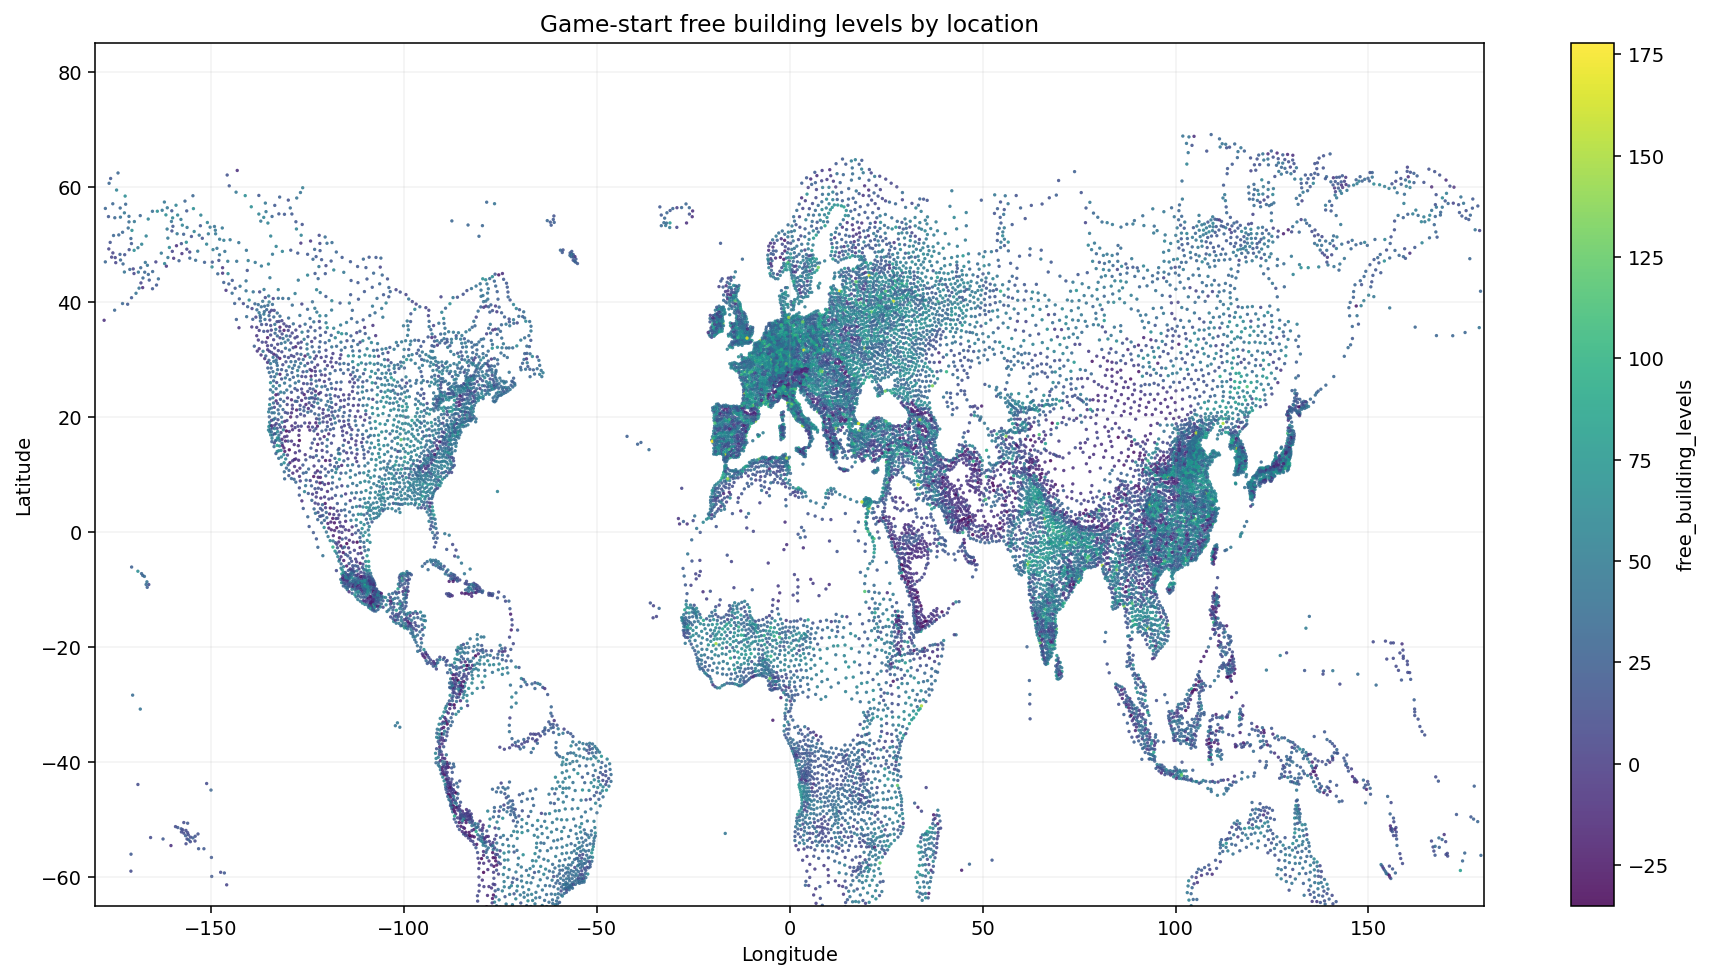

In [20]:
plot_location_world_map(
    plot_frame,
    "free_building_levels",
    title="Game-start free building levels by location",
    cmap="viridis",
)


## Building Efficiency World Map


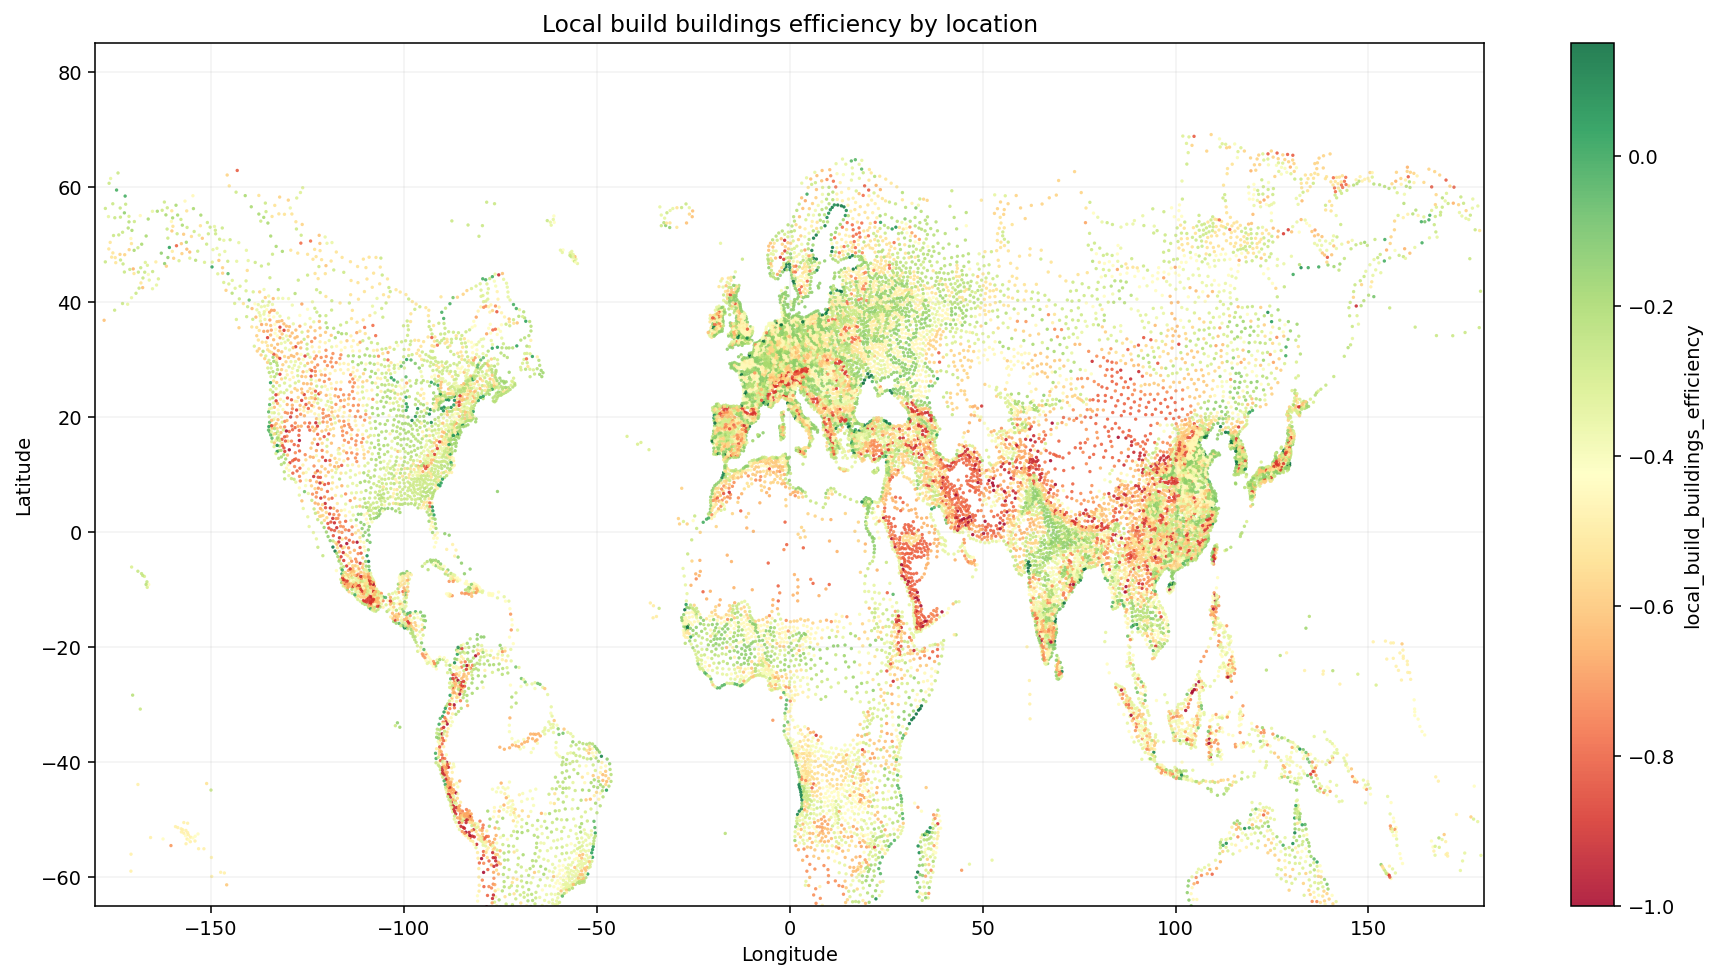

In [21]:
plot_location_world_map(
    plot_frame,
    LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
    title="Local build buildings efficiency by location",
    cmap="RdYlGn",
)


## Regional Aggregate Map


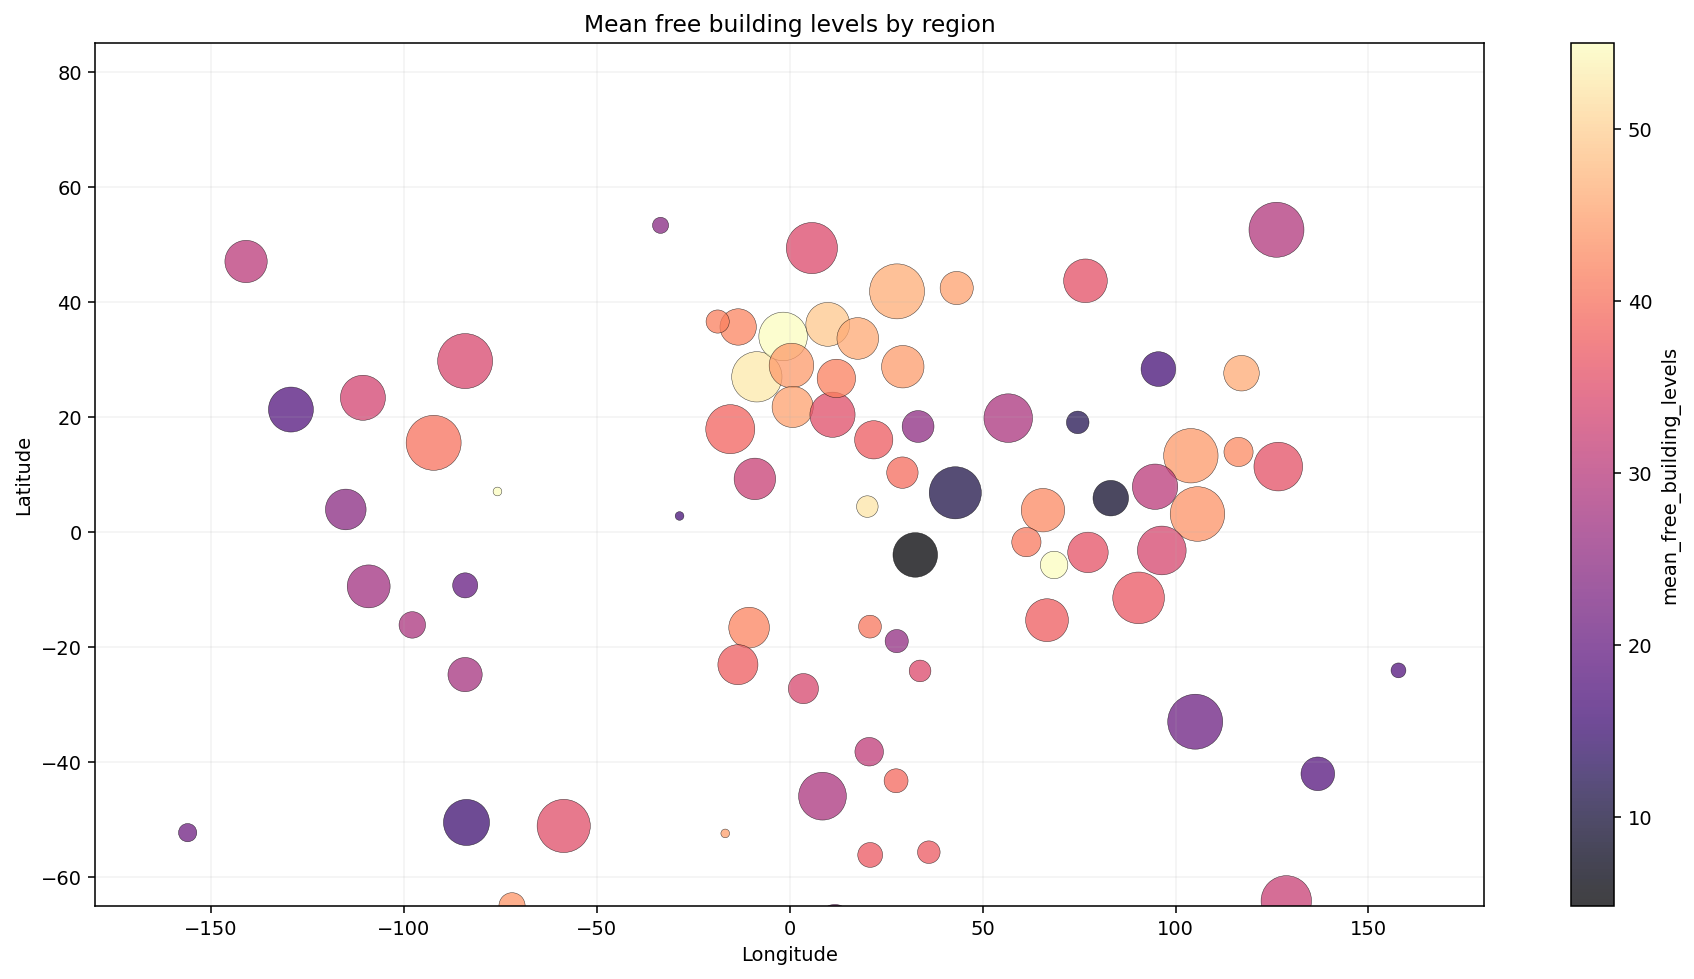

region,lon,lat,locations,mean_free_building_levels,total_free_building_levels
str,f64,f64,u32,f64,f64
"""russian_region""",27.80,41.84,560,46.31,25935.02
"""east_coast_region""",-92.32,15.50,628,40.10,25184.88
"""france_region""",-8.54,26.97,446,52.71,23510.10
"""north_china_region""",103.97,13.25,522,44.12,23031.68
"""east_china_region""",105.68,3.11,525,43.49,22831.78
"""north_german_region""",-1.72,34.00,416,54.82,22804.92
"""canada_region""",-84.15,29.71,573,34.15,19569.40
"""brazil_region""",-58.60,-51.14,499,35.22,17576.80
"""indochina_region""",90.42,-11.47,471,36.92,17387.18


In [22]:
region_plot = (
    plot_frame.group_by("region")
    .agg(
        pl.col("approx_lon").median().alias("lon"),
        pl.col("approx_lat").median().alias("lat"),
        pl.len().alias("locations"),
        pl.col("free_building_levels").mean().alias("mean_free_building_levels"),
        pl.col("free_building_levels").sum().alias("total_free_building_levels"),
    )
    .sort("total_free_building_levels", descending=True)
)
region_data = region_plot.to_dict(as_series=False)
region_vmin, region_vmax = color_limits(region_plot["mean_free_building_levels"])

plt.close("all")
fig, ax = plt.subplots(figsize=(16, 8), dpi=140)
sizes = [max(20, min(800, value * 1.5)) for value in region_data["locations"]]
scatter = ax.scatter(
    region_data["lon"],
    region_data["lat"],
    c=region_data["mean_free_building_levels"],
    s=sizes,
    cmap="magma",
    vmin=region_vmin,
    vmax=region_vmax,
    edgecolors="black",
    linewidths=0.25,
    alpha=0.75,
)
ax.set_xlim(-180, 180)
ax.set_ylim(-65, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Mean free building levels by region")
fig.colorbar(scatter, ax=ax, label="mean_free_building_levels")
ax.grid(alpha=0.15)
plt.show()

display(round_numeric_columns(region_plot.head(30)))
